# Moving Average vs Naive Forecast Evaluation Demo

This notebook provides a rigorous statistical comparison between a 3-point moving average forecasting method and a naive last-value baseline across synthetic time series with linear trends and Gaussian noise.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pandas==2.2.2')


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import json
import os
import urllib.request
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-0ece95-adaptive-smoothing-and-persistence-trade/main/round-1/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()

In [4]:
# Tunable configuration parameters
N_RUNS = 50
SERIES_LENGTH = 30
WINDOW_SIZE = 3
RANDOM_SEED = 42

## Synthetic Time Series Forecasting Evaluation

We simulate independent synthetic time series with linear trends and additive Gaussian noise. For each series, we generate predictions using both a 3-point moving average and a naive last-value persistence model, computing Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).

In [5]:
np.random.seed(RANDOM_SEED)

ma_sq_errors = []
naive_sq_errors = []
ma_abs_errors = []
naive_abs_errors = []

examples = []

for run in range(N_RUNS):
    t = np.arange(SERIES_LENGTH)
    trend = 0.1 * t
    noise = np.random.normal(0, 1.0, size=SERIES_LENGTH)
    series = trend + noise

    for i in range(WINDOW_SIZE, SERIES_LENGTH):
        ma_pred = np.mean(series[i-WINDOW_SIZE:i])
        ma_sq_err = float((series[i] - ma_pred) ** 2)
        ma_abs_err = float(abs(series[i] - ma_pred))

        naive_pred = series[i-1]
        naive_sq_err = float((series[i] - naive_pred) ** 2)
        naive_abs_err = float(abs(series[i] - naive_pred))

        ma_sq_errors.append(ma_sq_err)
        ma_abs_errors.append(ma_abs_err)
        naive_sq_errors.append(naive_sq_err)
        naive_abs_errors.append(naive_abs_err)

        ex = {
            "input": f"run_{run}_step_{i}",
            "output": str(series[i]),
            "metadata_run": run,
            "metadata_step": i,
            "predict_ma": float(ma_pred),
            "predict_naive": float(naive_pred),
            "eval_ma_mse": ma_sq_err,
            "eval_naive_mse": naive_sq_err
        }
        examples.append(ex)

ma_mse = float(np.mean(ma_sq_errors))
ma_rmse = float(np.sqrt(ma_mse))
ma_mae = float(np.mean(ma_abs_errors))

naive_mse = float(np.mean(naive_sq_errors))
naive_rmse = float(np.sqrt(naive_mse))
naive_mae = float(np.mean(naive_abs_errors))

t_stat, t_pval = stats.ttest_rel(ma_sq_errors, naive_sq_errors)
wilcoxon_stat, wilcoxon_pval = stats.wilcoxon(ma_sq_errors, naive_sq_errors)

metrics_agg = {
    "ma_mse": ma_mse,
    "ma_rmse": ma_rmse,
    "ma_mae": ma_mae,
    "naive_mse": naive_mse,
    "naive_rmse": naive_rmse,
    "naive_mae": naive_mae,
    "mse_improvement": float(naive_mse - ma_mse),
    "mae_improvement": float(naive_mae - ma_mae),
    "paired_t_statistic": float(t_stat),
    "paired_t_pvalue": float(t_pval),
    "wilcoxon_statistic": float(wilcoxon_stat),
    "wilcoxon_pvalue": float(wilcoxon_pval)
}

print("Aggregated Metrics Computed Successfully:")
print(json.dumps(metrics_agg, indent=2))

Aggregated Metrics Computed Successfully:
{
  "ma_mse": 1.3442461017115426,
  "ma_rmse": 1.1594162762836921,
  "ma_mae": 0.9180323462836193,
  "naive_mse": 2.008410256458957,
  "naive_rmse": 1.4171839176546412,
  "naive_mae": 1.1268167224016503,
  "mse_improvement": 0.6641641547474146,
  "mae_improvement": 0.20878437611803102,
  "paired_t_statistic": -11.476536422650119,
  "paired_t_pvalue": 3.714569711373058e-29,
  "wilcoxon_statistic": 305278.0,
  "wilcoxon_pvalue": 7.166315581924752e-26
}


## Results Summary & Visualization

We display the key error metrics and plot error distributions to compare the moving average model against the naive baseline.

=== PERFORMANCE COMPARISON ===
Moving Average MSE: 1.3442 (RMSE: 1.1594, MAE: 0.9180)
Naive Baseline MSE:  2.0084 (RMSE: 1.4172, MAE: 1.1268)
MSE Improvement:     0.6642
Paired t-test p-val: 3.71e-29
Wilcoxon p-val:      7.17e-26


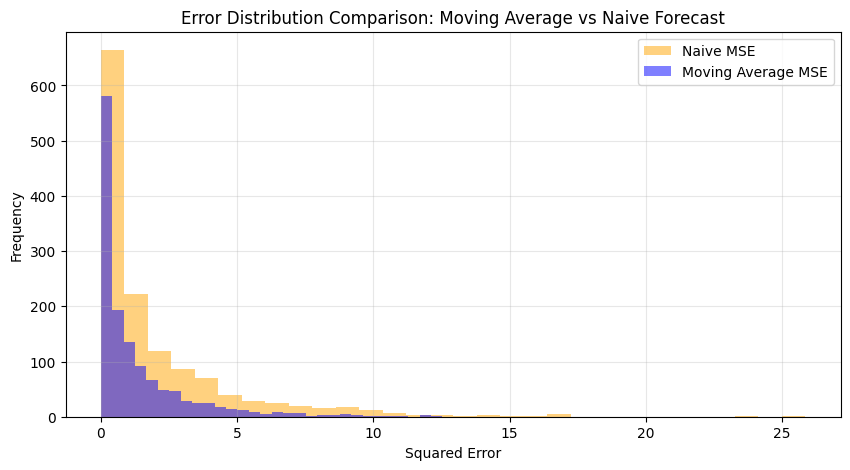

In [6]:
print("=== PERFORMANCE COMPARISON ===")
print(f"Moving Average MSE: {metrics_agg['ma_mse']:.4f} (RMSE: {metrics_agg['ma_rmse']:.4f}, MAE: {metrics_agg['ma_mae']:.4f})")
print(f"Naive Baseline MSE:  {metrics_agg['naive_mse']:.4f} (RMSE: {metrics_agg['naive_rmse']:.4f}, MAE: {metrics_agg['naive_mae']:.4f})")
print(f"MSE Improvement:     {metrics_agg['mse_improvement']:.4f}")
print(f"Paired t-test p-val: {metrics_agg['paired_t_pvalue']:.2e}")
print(f"Wilcoxon p-val:      {metrics_agg['wilcoxon_pvalue']:.2e}")

plt.figure(figsize=(10, 5))
plt.hist(naive_sq_errors, bins=30, alpha=0.5, label='Naive MSE', color='orange')
plt.hist(ma_sq_errors, bins=30, alpha=0.5, label='Moving Average MSE', color='blue')
plt.xlabel('Squared Error')
plt.ylabel('Frequency')
plt.title('Error Distribution Comparison: Moving Average vs Naive Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()